✅ Imagen cargada correctamente
Rectangulo → Hu Moments: [ 1.69561049e-01  1.00263900e-03  1.12415987e-08  1.12759419e-09
  3.65271732e-18 -7.87049436e-12  1.66575621e-18]
Rectangulo → Hu Moments: [ 1.67732462e-01  4.92557698e-04  8.50785471e-09  7.83931413e-10
  1.26045133e-18 -7.60121737e-12 -1.58431033e-18]
Triangulo → Hu Moments: [ 1.92404355e-01  3.30699025e-05  4.54130827e-03  1.00092011e-06
 -6.62222714e-11 -5.65334100e-09  1.29794482e-11]
Rectangulo → Hu Moments: [ 1.75754657e-01  3.11945670e-03  7.41754176e-10  7.84779918e-11
  1.46068825e-20 -1.50823565e-12 -1.20478603e-20]
Circulo → Hu Moments: [1.59157142e-01 2.71627211e-10 1.09992400e-08 8.00135476e-15
 7.12348866e-26 1.09865159e-19 2.36656579e-26]


(np.float64(-0.5), np.float64(919.5), np.float64(922.5), np.float64(-0.5))

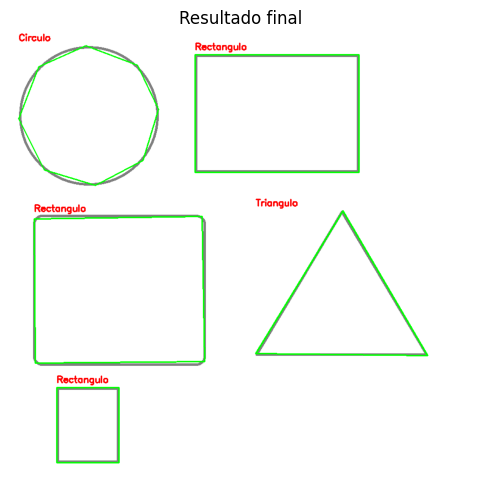

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("FOTOS.png")

if img is None:
    print("❌ Error: no se encontró la imagen")
else:
    print("✅ Imagen cargada correctamente")


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 1)
canny = cv2.Canny(blur, 50, 150)


contornos, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


for cnt in contornos:
    area = cv2.contourArea(cnt)

    if area > 300:  
        perimetro = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * perimetro, True)

        x, y, w, h = cv2.boundingRect(approx)
        vertices = len(approx)

        if vertices == 3:
            figura = "Triangulo"
        elif vertices == 4:
            aspect_ratio = w / float(h)
            if 0.9 < aspect_ratio < 1.1:
                figura = "Cuadrado"
            else:
                figura = "Rectangulo"
        elif vertices > 4:
            figura = "Circulo"
        else:
            figura = "Desconocido"

        momentos = cv2.moments(cnt)
        hu = cv2.HuMoments(momentos)

        print(f"{figura} → Hu Moments: {hu.flatten()}")

        cv2.drawContours(img_rgb, [approx], -1, (0,255,0), 2)
        cv2.putText(img_rgb, figura, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Resultado final")
plt.axis("off")